### Basic Data Loading and Exploration

In this exercise, you'll work with a synthetic dataset about houses. You'll practice basic exploratory data analysis (EDA), and create simple visualizations to understand the data better.

The dataset contains the following columns:
- 'area': House area in square feet (numeric)
- 'bedrooms': Number of bedrooms (numeric)
- 'age': Age of the house in years (numeric)
- 'neighborhood': Categorical feature representing different neighborhoods
- 'distance_to_city_center': Distance to city center in miles (numeric)
- 'price': House price in thousands of dollars (target variable)

Your tasks:
1. Load the generated data into a pandas DataFrame
2. Explore the basic properties of the dataset
3. Create visualizations to better understand the data
4. Analyze correlations between features


First, we'll create some data to process.

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate synthetic data
np.random.seed(42)
n_samples = 1000

area = np.random.uniform(1000, 5000, n_samples)
bedrooms = np.random.randint(1, 6, n_samples)
age = np.random.uniform(1, 50, n_samples)
neighborhood = np.random.choice(['A', 'B', 'C', 'D', 'E'], n_samples)
distance_to_city_center = np.random.exponential(scale=5, size=n_samples)

price = (
    10 * np.log(area) +
    5 * bedrooms -
    2 * age +
    np.where(neighborhood == 'A', 50, 0) +
    np.where(neighborhood == 'C', 30, 0) +
    np.where(neighborhood == 'E', 10, 0) +
    np.where(neighborhood == 'D', -20, 0) +
    np.where(neighborhood == 'B', -40, 0) -
    20 * np.log(distance_to_city_center + 1) +
    np.random.normal(0, 10, n_samples)
)

# Create DataFrame
df = pd.DataFrame({
    'area': area,
    'bedrooms': bedrooms,
    'age': age,
    'neighborhood': neighborhood,
    'distance_to_city_center': distance_to_city_center,
    'price': price
})

# Add some missing values

df.loc[np.random.choice(df.index, 50, replace=False), 'neighborhood'] = np.nan
df.loc[np.random.choice(df.index, 30, replace=False), 'bedrooms'] = np.nan
df.loc[np.random.choice(df.index, 20, replace=False), 'age'] = np.nan


## Exercise 1

#### Display basic information about the dataset (hint: use `.info()`)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   area                     1000 non-null   float64
 1   bedrooms                 970 non-null    float64
 2   age                      980 non-null    float64
 3   neighborhood             950 non-null    object 
 4   distance_to_city_center  1000 non-null   float64
 5   price                    1000 non-null   float64
dtypes: float64(5), object(1)
memory usage: 47.0+ KB


## Exercise 2

#### Display the dataframe 

In [4]:
df

,area,bedrooms,age,neighborhood,distance_to_city_center,price
0,2498.160475,4.0,25.277153,B,15.125273,-61.657557
1,4802.857226,3.0,19.931097,C,0.964840,79.914053
2,3927.975767,5.0,23.056097,NaN,4.193493,-11.083783
3,3394.633937,1.0,12.121270,NaN,4.329348,9.061742
4,1624.074562,5.0,44.580155,NaN,3.363042,49.280903
...,...,...,...,...,...,...
995,1366.328293,2.0,24.585335,D,16.854162,-47.713077
996,4669.254302,4.0,44.986059,C,2.500709,30.916394
997,1547.274524,5.0,34.043100,A,0.700435,41.363561
998,4800.949415,4.0,7.712954,E,5.569272,61.525617


## Exercise 3

#### Calculate summary statistics (use `.describe()`)

In [5]:
df.describe()

,area,bedrooms,age,distance_to_city_center,price
count,1000.000000,970.000000,980.000000,1000.000000,1000.000000
mean,2961.026213,3.047423,25.701926,4.786029,20.052093
std,1168.549448,1.430112,14.297999,4.856130,48.934901
min,1018.528092,1.000000,1.009232,0.000154,-114.546204
25%,1943.893070,2.000000,12.865136,1.352034,-14.402742
50%,2987.229506,3.000000,26.558701,3.318686,22.709886
75%,3977.278352,4.000000,37.815854,6.524832,55.105175
max,4998.870693,5.000000,49.985976,38.617648,150.497437


## Exercise 4

#### Create a histogram of the 'price' column

- Hint: Use plt.hist() or sns.histplot()

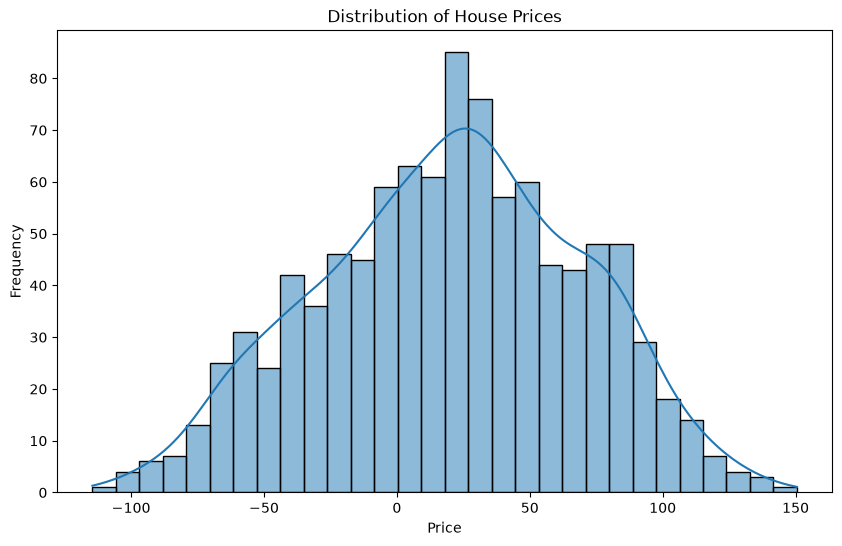

In [6]:
plt.figure(figsize=(10, 6))
# Your code here
sns.histplot(data=df, x='price', bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


## Exercise 5

#### Create a scatter plot of 'area' vs 'price'

- Hint: Use plt.scatter() or sns.scatterplot()

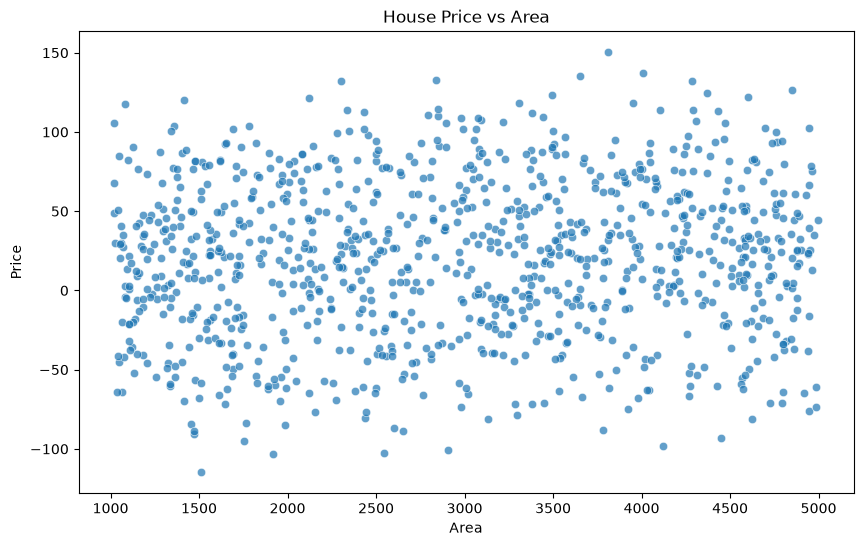

In [7]:

# TODO: 
plt.figure(figsize=(10, 6))
# Your code here
sns.scatterplot(data=df, x='area', y='price', alpha=0.7)
plt.title('House Price vs Area')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()


## Exercise 6

#### Calculate and print the correlation between numeric columns

- Hint: Use df.corr() and focus on numeric columns only

In [8]:

# TODO: 
# Select numeric columns only
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Get the correlation matrix
correlation_matrix = df[numeric_columns].corr()
print("Correlation Matrix:")
print(correlation_matrix)


Correlation Matrix:
                             area  bedrooms       age  \
area                     1.000000 -0.036209 -0.004771   
bedrooms                -0.036209  1.000000  0.002617   
age                     -0.004771  0.002617  1.000000   
distance_to_city_center  0.013125 -0.031614  0.051266   
price                    0.078197  0.152051 -0.596060   

                         distance_to_city_center     price  
area                                    0.013125  0.078197  
bedrooms                               -0.031614  0.152051  
age                                     0.051266 -0.596060  
distance_to_city_center                 1.000000 -0.356431  
price                                  -0.356431  1.000000  


## Exercise 7

#### Create a heatmap of the correlation matrix

- Hint: use `sns.heatmap`

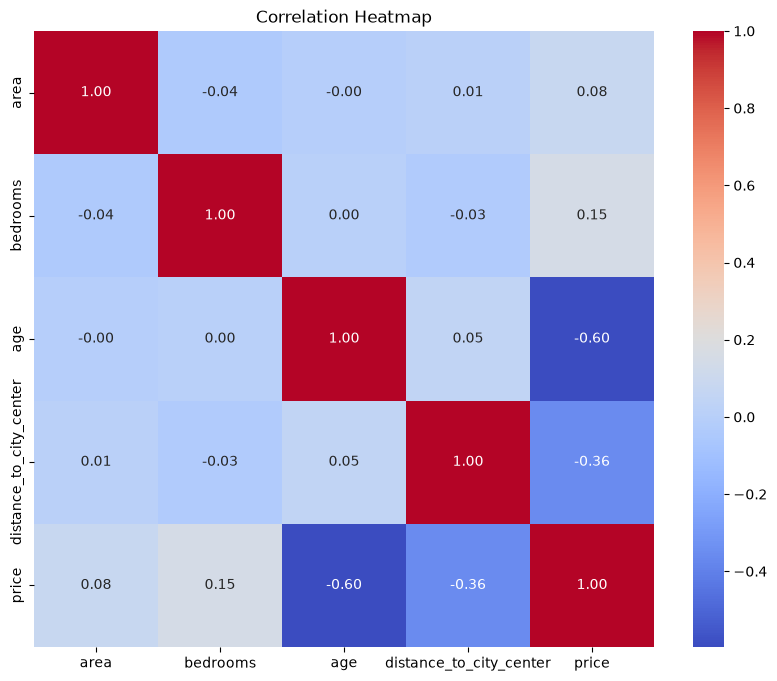

In [9]:

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
# TODO: Your code here
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Heatmap')
plt.show()

## Exercise 8

#### Identify missing values

- Hint: Use df.isnull().sum()

In [10]:
# TODO: Check for missing values in each column
# Hint: Use df.isnull().sum()
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values)

Missing values in each column:
area                        0
bedrooms                   30
age                        20
neighborhood               50
distance_to_city_center     0
price                       0
dtype: int64


## Exercise 9: 

#### Calculate the percentage of missing values in each column

- Hint: Divide the missing value counts by the total number of rows and multiply by 100


Percentage of missing values in each column:
area                       0.0
bedrooms                   3.0
age                        2.0
neighborhood               5.0
distance_to_city_center    0.0
price                      0.0
dtype: float64


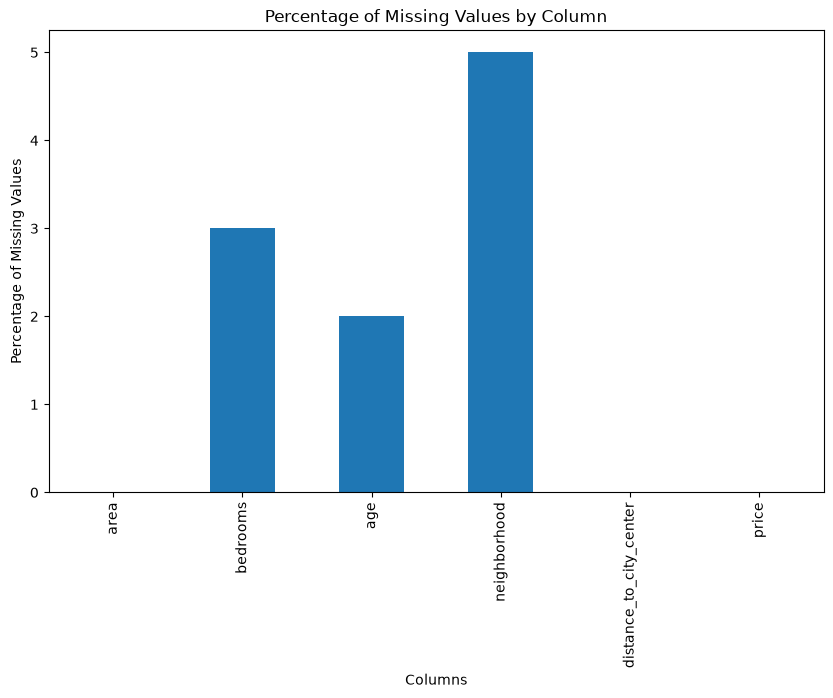

In [ ]:

missing_percentages = (missing_values / len(df)) * 100
print("\nPercentage of missing values in each column:")
print(missing_percentages)

# Visualize missing values
plt.figure(figsize=(10, 10))
missing_percentages.plot(kind='bar')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.show()